In [1]:
import scarf
import scarf.plotting as splt

scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name="tenx_5K_pbmc_rnaseq", as_zarr=True, save_path="scarf_datasets"
)

Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



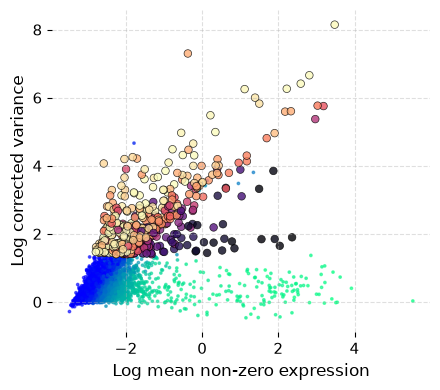

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.6s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.80%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 9.1s (7/7 steps, 9.0s in logged steps)



Training UMAP:   0%|                                                                                          …

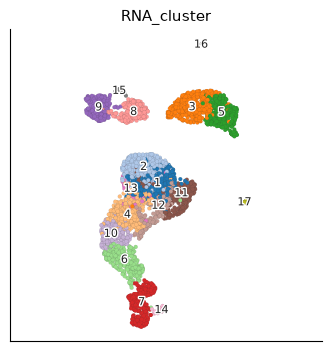

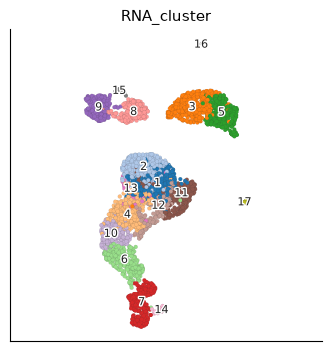

In [3]:
ds = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr")

ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15)
ds.run_clustering(n_clusters=15)
ds.run_umap(n_epochs=250, parallel=True)

splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cluster",
).figure

In [4]:
ds.run_topacedo_sampler(cluster_key="RNA_cluster", max_sampling_rate=0.1)

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram:  40%|████      | 1595/3939 [00:00<00:00, 9333.43it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 21869.68it/s]

INFO: 392 cells (9.95%) sub-sampled. Subsample to Seed (166 cells) ratio: 2.361


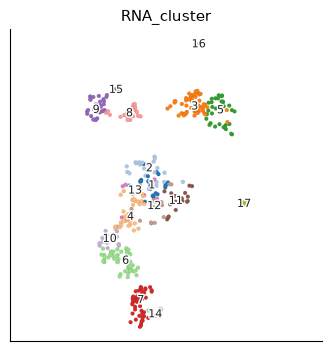

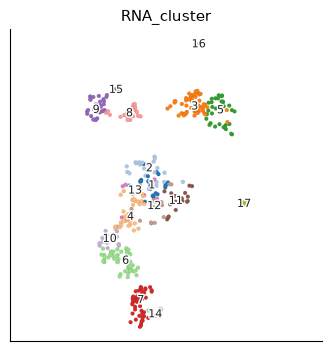

In [5]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cluster",
    subset_by="RNA_sketched",
).figure

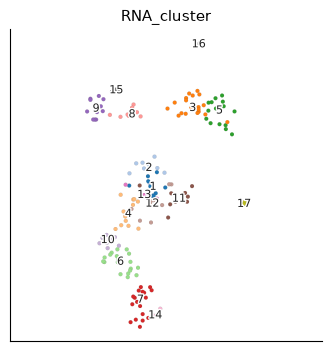

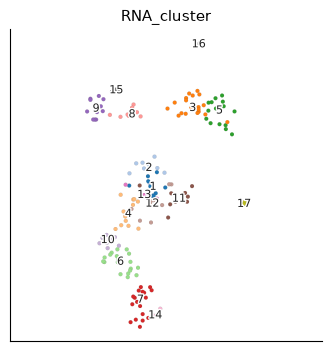

In [6]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cluster",
    subset_by="RNA_sketch_seeds",
).figure

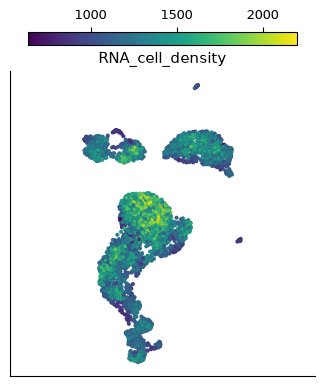

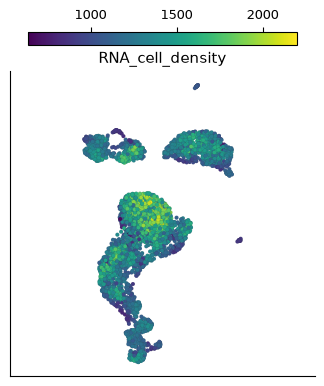

In [7]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cell_density",
).figure

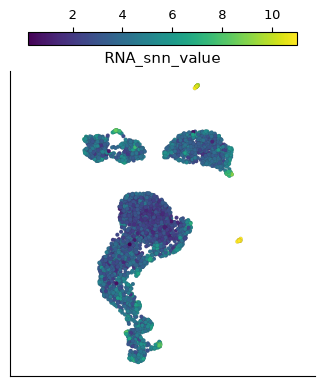

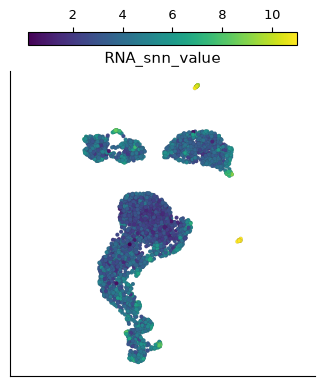

In [8]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_snn_value",
).figure

In [9]:
writer = scarf.SubsetZarr(
    zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr",
    assays=[ds.RNA],
    cell_key="RNA_sketched",
    reset_cell_filter=False,
)
writer.dump()

Writing countsT shape=(33538, 392) chunks=(33538, 392)



In [10]:
ds2 = scarf.DataStore("scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr")

In [11]:
ds2

DataStore has 392 (392) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'RNA_cell_density', 'RNA_snn_value', 'RNA_sketch_seeds', 'RNA_tSNE1', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_cluster', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_sketched', 'RNA_UMAP1'
   RNA assay has 8869 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [12]:
adata = ds2.to_anndata()

In [13]:
adata

AnnData object with n_obs × n_vars = 392 × 33538
    obs: 'I', 'names', 'RNA_tSNE2', 'RNA_cell_density', 'RNA_percentMito', 'RNA_snn_value', 'RNA_tSNE1', 'RNA_sketch_seeds', 'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_cluster', 'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_sketched', 'RNA_UMAP1'
    var: 'I', 'names', 'nCells', 'dropOuts'